In [2]:
!pip install qiskit
!pip install qiskit[visualization]
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=61f745b92d9c00baf78f1cdd31714b6e014aa1de7b1bfe3c5839a5ea2eb2a174
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.9 MB/s eta 0:00:00


In [3]:
#Step 1: Import Required Libraries
from qiskit import *
from qiskit_aer import Aer
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Step 2: Create Controlled Unitary (U) — Phase Gate
def controlled_unitary(qc, ctrl_qubit, tgt_qubit, power):
    angle = 2 * np.pi * (1/4) * (2**power)  # φ = 1/4 (example)
    qc.cp(angle, ctrl_qubit, tgt_qubit)


/tmp/ipython-input-404625772.py:15: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(3, inverse=True, do_swaps=True).to_gate(), [0, 1, 2])


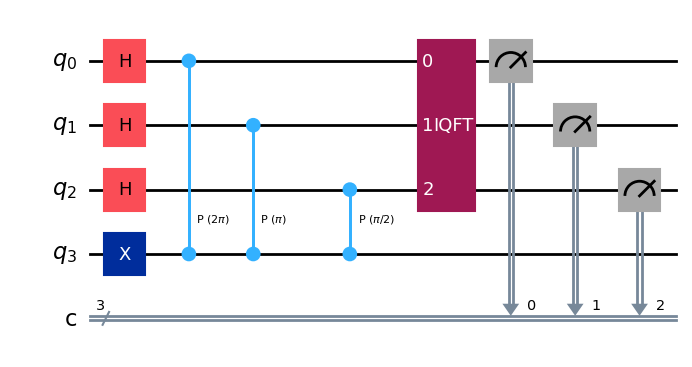

In [5]:
# Step 3: Build QPE Circuit with 3 Ancilla Qubits and 1 Eigenstate Qubit
qc = QuantumCircuit(4, 3)  # 3 ancilla qubits, 1 eigenstate qubit
# Initialize eigenstate qubit to |1⟩
qc.x(3)

# Apply Hadamards to ancilla qubits
qc.h([0, 1, 2])

# Apply controlled-U operations
controlled_unitary(qc, 0, 3, 2)
controlled_unitary(qc, 1, 3, 1)
controlled_unitary(qc, 2, 3, 0)

# Apply inverse QFT to ancilla qubits
qc.append(QFT(3, inverse=True, do_swaps=True).to_gate(), [0, 1, 2])

# Measure ancilla qubits
qc.measure([0, 1, 2], [0, 1, 2])

qc.draw('mpl')


{'101': 38, '001': 226, '010': 249, '110': 273, '011': 33, '111': 205}


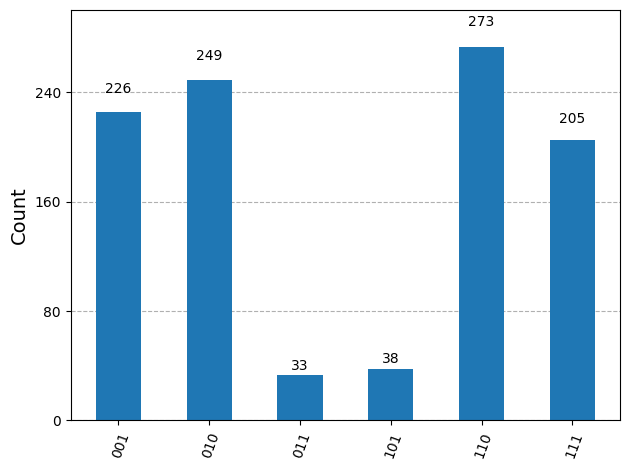

In [8]:
# Step 4: Simulate the Circuit
backend = Aer.get_backend('qasm_simulator')
compiled = transpile(qc, backend)
job = backend.run(compiled, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)